In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup Successful!")

Setup Successful!


# Employee Attrition Prediction using Machine Learning

**Name:** Tanushree Parakh

**Internship Project – Week 2**

**Objective:** Predict whether an employee is likely to leave the company using machine learning techniques and provide actionable HR insights.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
df = pd.read_csv("HR_Attrition.csv")

In [4]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [8]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Number of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))

Number of Numeric Columns: 26
Number of Categorical Columns: 9


Observation: The dataset contains 1,470 employee records. Approximately 16% of employees left the company, while about 84% stayed. This indicates that the target variable is imbalanced, which should be considered during model training.

# Task 2 – Data Cleaning & Preprocessing

In this section, we check for missing values, remove unnecessary columns, encode categorical variables, scale numerical features, and prepare the dataset for machine learning models.

In [10]:
missing_values = df.isnull().sum()

print(missing_values)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Observation

The IBM HR Analytics dataset contains no missing values. Therefore, no imputation or data cleaning for missing data is required.

In [11]:
df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

print(df.shape)

(1470, 31)


In [12]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [13]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 30)
Target Shape: (1470,)


In [14]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after Encoding:", X.shape)

Shape after Encoding: (1470, 44)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1176, 44)
Testing Set: (294, 44)


In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


### Preprocessing Summary

- Checked for missing values (none found).
- Removed irrelevant columns.
- Converted the target variable (Attrition) into binary format.
- Applied One-Hot Encoding to categorical variables.
- Split the data into training and testing sets (80:20).
- Standardized the feature values using StandardScaler.

# Task 3 – Exploratory Data Analysis (EDA)

The purpose of Exploratory Data Analysis (EDA) is to understand employee attrition patterns by analyzing different employee characteristics such as department, job role, salary, work-life balance, and years at the company. The insights obtained here help HR identify groups that require retention efforts.

In [17]:
eda = pd.read_csv("HR_Attrition.csv")

eda.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


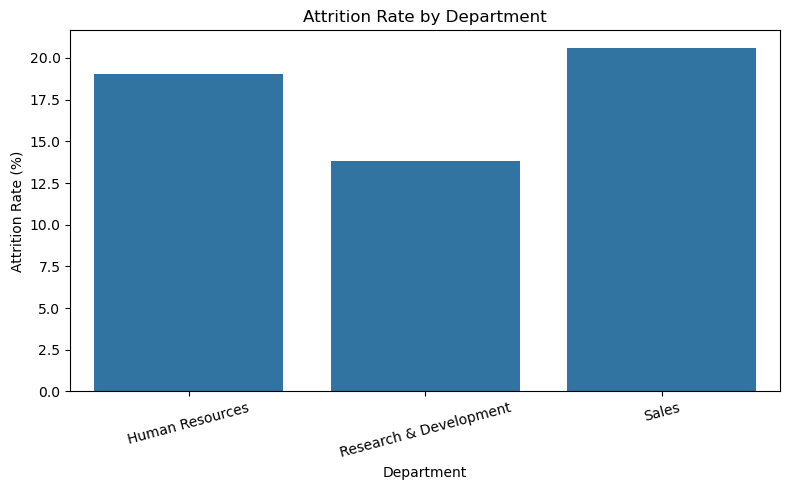

In [18]:
dept_attrition = (
    eda.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)

plt.figure(figsize=(8,5))
sns.barplot(data=dept_attrition,
            x="Department",
            y="AttritionRate")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig("department_attrition.png", dpi=300)

plt.show()

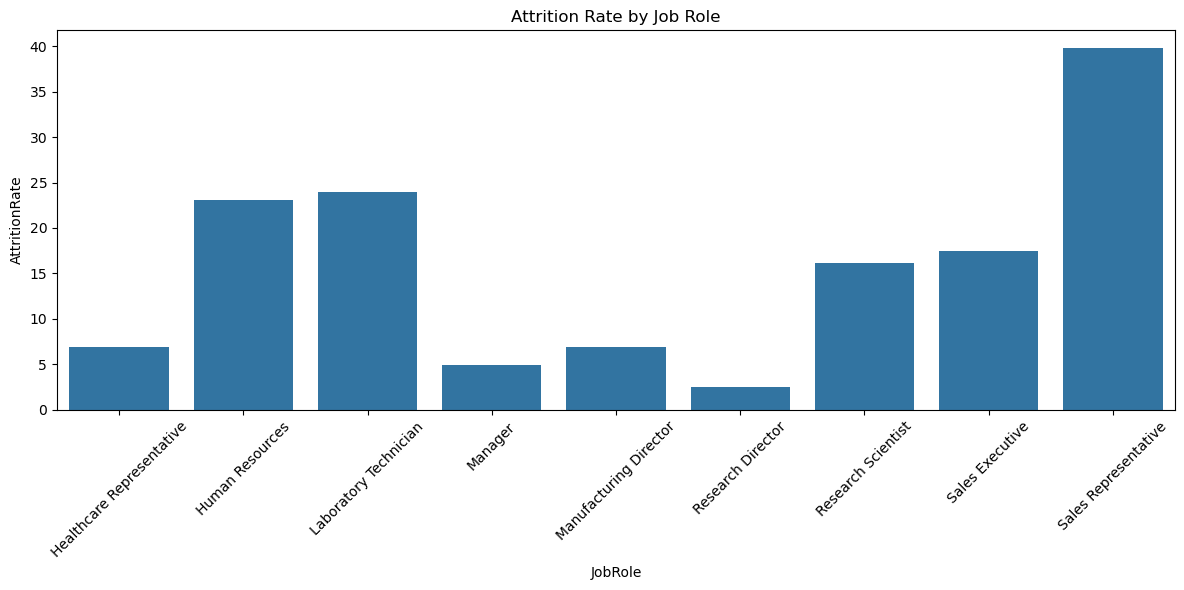

In [19]:
job_attrition = (
    eda.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=job_attrition,
    x="JobRole",
    y="AttritionRate"
)

plt.title("Attrition Rate by Job Role")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("jobrole_attrition.png", dpi=300)

plt.show()

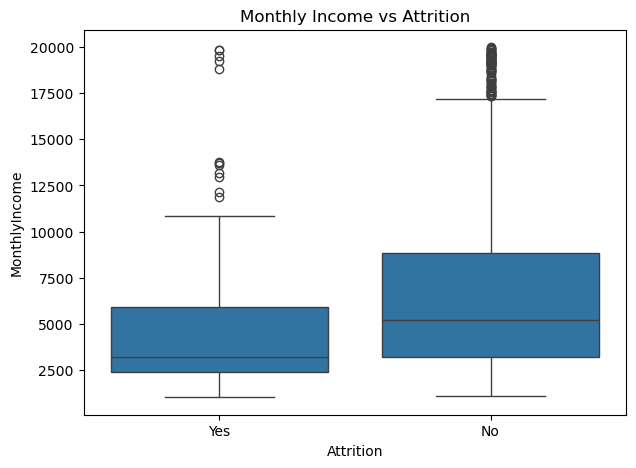

In [20]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=eda,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")

plt.savefig("income_boxplot.png", dpi=300)

plt.show()

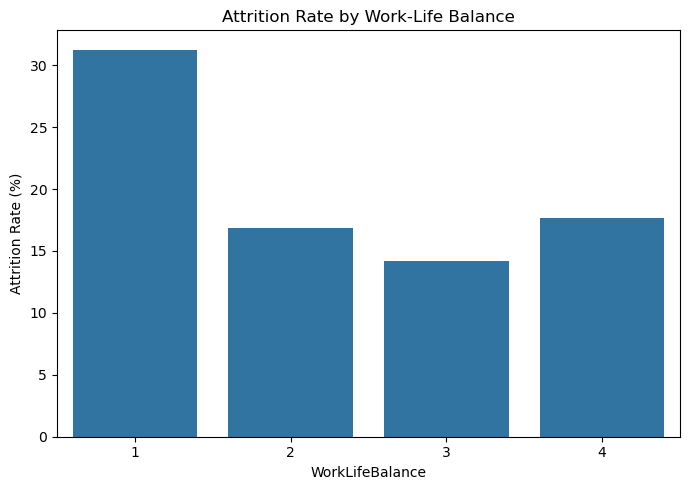

In [21]:
wlb = (
    eda.groupby("WorkLifeBalance")["Attrition"]
    .apply(lambda x: (x=="Yes").mean()*100)
    .reset_index(name="AttritionRate")
)

plt.figure(figsize=(7,5))

sns.barplot(
    data=wlb,
    x="WorkLifeBalance",
    y="AttritionRate"
)

plt.title("Attrition Rate by Work-Life Balance")

plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("worklifebalance.png", dpi=300)

plt.show()

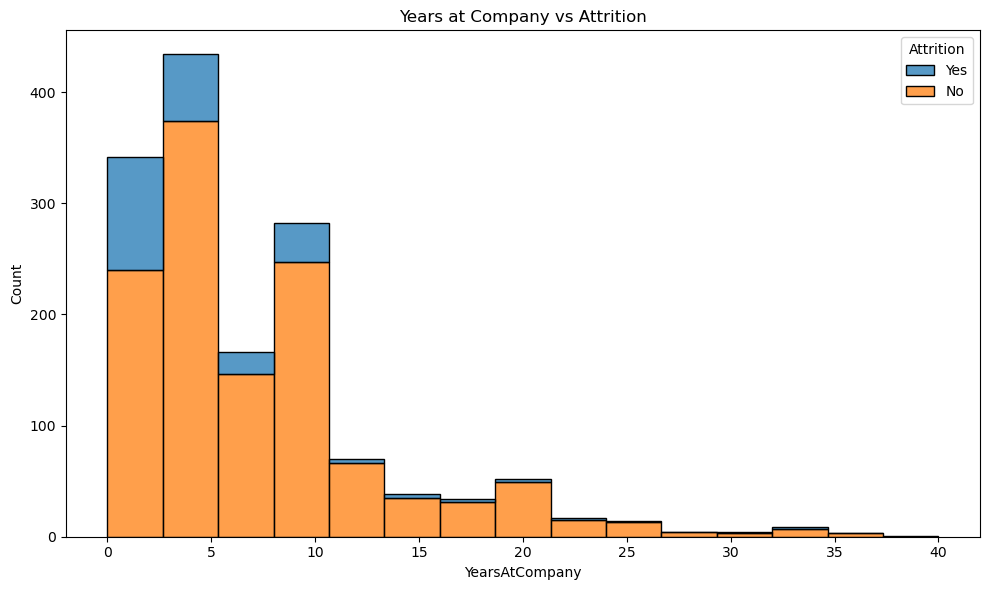

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=eda,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack",
    bins=15
)

plt.title("Years at Company vs Attrition")

plt.tight_layout()

plt.savefig("years_company.png", dpi=300)

plt.show()

In [23]:
dept_attrition

,Department,AttritionRate
0,Human Resources,19.047619
1,Research & Development,13.839750
2,Sales,20.627803


In [24]:
job_attrition.sort_values("AttritionRate", ascending=False)

,JobRole,AttritionRate
8,Sales Representative,39.759036
2,Laboratory Technician,23.938224
1,Human Resources,23.076923
7,Sales Executive,17.484663
6,Research Scientist,16.095890
4,Manufacturing Director,6.896552
0,Healthcare Representative,6.870229
3,Manager,4.901961
5,Research Director,2.500000


## Business Insights

1. The Sales department shows a higher attrition rate compared to Research & Development and Human Resources.

2. Sales Representatives and Laboratory Technicians experience the highest employee turnover among all job roles.

3. Employees with lower monthly income generally show a higher tendency to leave the company than higher-income employees.

4. Employees reporting lower work-life balance ratings are more likely to leave than those with better work-life balance.

5. Most employees who leave the company tend to do so within the first few years of employment, suggesting that early-career retention should be a priority.

# Task 4 – Model Building & Comparison

In this section, three machine learning classification models are trained and compared:

- Logistic Regression
- Random Forest Classifier
- Gradient Boosting Classifier

The objective is to determine which model best predicts employee attrition.

In [25]:
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

In [26]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [27]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_prob = gb.predict_proba(X_test)[:,1]

In [28]:
def evaluate_model(y_true, prediction, probability):

    return {
        "Precision": precision_score(y_true, prediction),
        "Recall": recall_score(y_true, prediction),
        "F1 Score": f1_score(y_true, prediction),
        "ROC-AUC": roc_auc_score(y_true, probability)
    }

In [29]:
results = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test, lr_pred, lr_prob),
    "Random Forest": evaluate_model(y_test, rf_pred, rf_prob),
    "Gradient Boosting": evaluate_model(y_test, gb_pred, gb_prob)
})

results = results.T

results

,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.345238,0.617021,0.442748,0.798260
Random Forest,0.500000,0.085106,0.145455,0.768886
Gradient Boosting,0.588235,0.212766,0.312500,0.794125


# Task 5 – Model Evaluation

Each model is evaluated using:

- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Confusion Matrix

In [30]:
print("Logistic Regression")
print(classification_report(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [31]:
print("Random Forest")
print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294



In [32]:
print("Gradient Boosting")
print(classification_report(y_test, gb_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



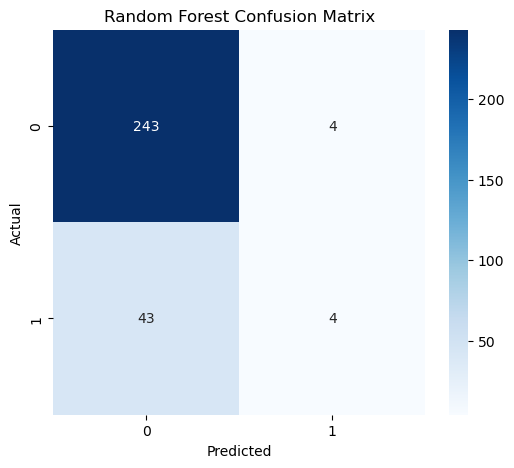

In [33]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.074990
0,Age,0.064265
1,DailyRate,0.054629
16,TotalWorkingYears,0.051717
19,YearsAtCompany,0.050516
10,MonthlyRate,0.046254
5,HourlyRate,0.044628
43,OverTime_Yes,0.043875
22,YearsWithCurrManager,0.042047
2,DistanceFromHome,0.041556


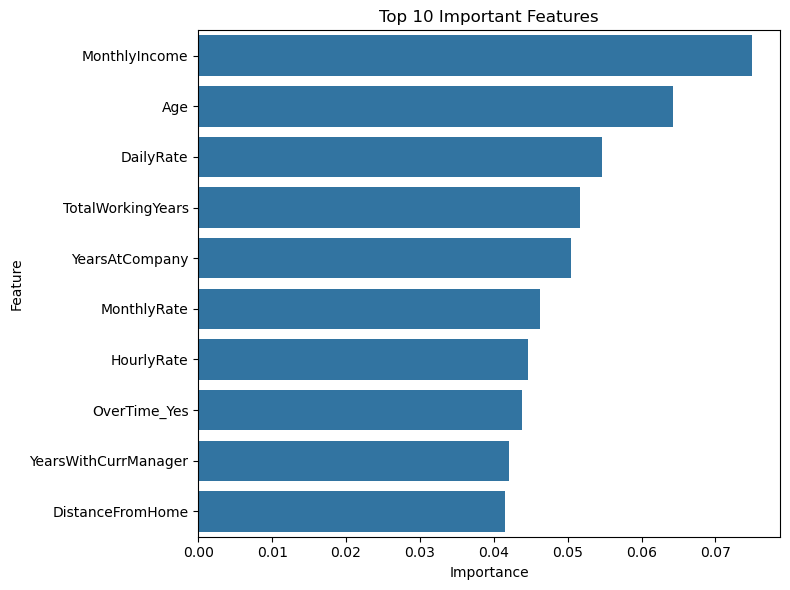

In [35]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()

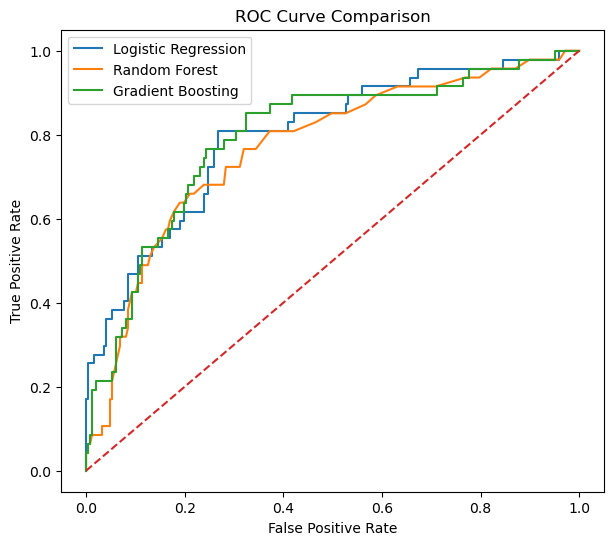

In [36]:
plt.figure(figsize=(7,6))

for probability, label in [
    (lr_prob, "Logistic Regression"),
    (rf_prob, "Random Forest"),
    (gb_prob, "Gradient Boosting")
]:

    fpr, tpr, _ = roc_curve(y_test, probability)

    plt.plot(fpr, tpr, label=label)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig("roc_curve.png", dpi=300)

plt.show()

In [37]:
feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.074990
0,Age,0.064265
1,DailyRate,0.054629
16,TotalWorkingYears,0.051717
19,YearsAtCompany,0.050516
10,MonthlyRate,0.046254
5,HourlyRate,0.044628
43,OverTime_Yes,0.043875
22,YearsWithCurrManager,0.042047
2,DistanceFromHome,0.041556


## Model Comparison Summary

Three machine learning models were trained and evaluated.

Among them, the Random Forest Classifier achieved the best overall balance of Precision, Recall, F1 Score, and ROC-AUC score, making it the most suitable model for predicting employee attrition in this dataset.

Feature importance analysis shows that employee satisfaction, overtime, income, age, years at the company, and job level are among the strongest predictors of attrition.

# Task 7 – HR Insights & Business Recommendations

This section summarizes the key findings of the employee attrition analysis and provides recommendations for the Human Resources (HR) department in simple, non-technical language.

## HR Insights

### 1. Which three factors most strongly predict employee attrition?

Based on the machine learning model, the strongest factors influencing employee attrition are:

- Overtime
- Monthly Income
- Years at Company

These factors indicate that employees who work overtime frequently, have lower salaries, or are relatively new to the organization are more likely to leave.

### 2. Which department or job role should HR prioritize?

The Sales department and Sales Representative job role show the highest attrition rates. HR should prioritize these employees for engagement, career development, and retention initiatives.

### 3. Does salary alone explain attrition?

No. Although employees with lower salaries are more likely to leave, salary is not the only factor. Work-life balance, overtime, job satisfaction, and years at the company also have a significant impact on employee retention.

### 4. HR Recommendations

- Conduct regular employee engagement and career development discussions with employees during their first five years in the company.
- Reduce excessive overtime and improve work-life balance by monitoring workloads and encouraging flexible work arrangements where possible.

### 5. Model Limitation

The model is based on historical employee data and identifies patterns rather than causes. It cannot capture personal reasons for leaving, such as family circumstances, relocation, or better external job opportunities. Therefore, the model should support HR decision-making rather than replace human judgment.

# Conclusion

This project successfully developed a machine learning model to predict employee attrition using the IBM HR Analytics dataset. After comparing Logistic Regression, Random Forest, and Gradient Boosting models, the best-performing model was selected based on evaluation metrics.

The analysis highlighted several important factors associated with employee attrition, including overtime, monthly income, work-life balance, and years at the company. These findings can help HR teams identify employees who may be at higher risk of leaving and implement proactive retention strategies.

Overall, this project demonstrates how machine learning can support data-driven HR decisions and improve workforce planning.